# Sistem Pakar Deteksi & Rekomendasi Burnout Mahasiswa TI
## Kelompok 5 — SBP UTS (Versi Perbaikan)

### 📋 Ringkasan Perbaikan dari Versi Sebelumnya
| # | Masalah Lama | Perbaikan |
|---|---|---|
| 1 | Label `'very high'` tidak ada di data → distribusi salah | Label sekarang berdasarkan hasil `value_counts()` aktual |
| 2 | `tugas_deadline` == `praktikum_pressure` selalu (threshold sama) | Threshold dibedakan secara logis |
| 3 | CF tidak pernah dipanggil / dijalankan | Ditambahkan pemanggilan `cf_inference` yang benar |
| 4 | Rule terlalu berlapis, banyak jalur tidak pernah tercapai | Rule disederhanakan & ditambah jalur OR untuk intermediate |
| 5 | Naive Bayes predict pada seluruh data (data leakage) | Evaluasi dipisah train/test dengan benar |
| 6 | Tidak ada analisis EDA mendalam | Ditambah korelasi, distribusi fakta, confusion matrix |
| 7 | Tidak ada rekomendasi output | Ditambah sistem rekomendasi berbasis hasil inferensi |

---
# BAGIAN 1 — Data Collection & EDA

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
print("✅ Semua library berhasil diimport.")
print(f"   pandas {pd.__version__} | numpy {np.__version__}")

✅ Semua library berhasil diimport.
   pandas 2.2.2 | numpy 2.0.2


In [ ]:
# ── Load dataset ──────────────────────────────────────────────
df = pd.read_csv('student_mental_health_burnout.csv')

print(f"Jumlah data : {len(df):,} baris × {df.shape[1]} kolom")
print(f"Kolom       : {list(df.columns)}")
print()
df.head(5)

Jumlah data : 62,709 baris × 20 kolom
Kolom       : ['student_id', 'age', 'gender', 'course', 'year', 'daily_study_hours', 'daily_sleep_hours', 'screen_time_hours', 'stress_level', 'anxiety_score', 'depression_score', 'academic_pressure_score', 'financial_stress_score', 'social_support_score', 'physical_activity_hours', 'sleep_quality', 'attendance_percentage', 'cgpa', 'internet_quality', 'burnout_level']



,student_id,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_level
0,100001,23,Male,BTech,1st,4.3,6.8,6.1,High,10,3,4.0,2.0,6.0,1.8,Average,66.5,9.63,Good,High
1,100002,20,Male,BTech,3rd,1.4,4.7,3.0,High,2,10,8.0,5.0,9.0,1.9,Poor,55.8,6.04,Poor,Low
2,100003,24,Female,BCA,4th,3.7,4.8,1.5,Low,2,7,8.0,6.0,3.0,0.8,Good,85.0,8.31,Good,High
3,100004,21,Male,BSc,4th,1.6,6.7,7.0,High,3,3,4.0,9.0,9.0,0.7,Poor,89.1,5.95,Good,High
4,100005,23,Other,BSc,4th,2.0,6.7,5.4,High,7,7,6.0,4.0,4.0,1.7,Good,58.7,8.51,Good,Low


In [ ]:
# ── Informasi tipe data & missing values ──────────────────────
print("=== Tipe Data ===")
print(df.dtypes.to_string())
print()
print("=== Missing Values ===")
mv = df.isnull().sum()
print(mv[mv > 0] if mv.any() else "Tidak ada missing values ✅")

=== Tipe Data ===
student_id                   int64
age                          int64
gender                      object
course                      object
year                        object
daily_study_hours          float64
daily_sleep_hours          float64
screen_time_hours          float64
stress_level                object
anxiety_score                int64
depression_score             int64
academic_pressure_score    float64
financial_stress_score     float64
social_support_score       float64
physical_activity_hours    float64
sleep_quality               object
attendance_percentage      float64
cgpa                       float64
internet_quality            object
burnout_level               object

=== Missing Values ===
academic_pressure_score    1
financial_stress_score     1
social_support_score       1
physical_activity_hours    1
sleep_quality              1
attendance_percentage      1
cgpa                       1
internet_quality           1
burnout_level             

In [ ]:
# ================================================================
# [BARU] CEK DISTRIBUSI AKTUAL burnout_level
# PENTING: Ini adalah langkah yang sebelumnya dilewati dan
# menyebabkan label ground truth salah karena diasumsikan ada
# nilai 'very high' padahal tidak ada di dataset.
# ================================================================
print("=== Distribusi burnout_level (AKTUAL) ===")
print(df['burnout_level'].value_counts())
print()
print("=== Distribusi stress_level (AKTUAL) ===")
print(df['stress_level'].value_counts())
print()
print("=== Distribusi sleep_quality (AKTUAL) ===")
print(df['sleep_quality'].value_counts())
print()
print("=== Distribusi internet_quality (AKTUAL) ===")
print(df['internet_quality'].value_counts())

=== Distribusi burnout_level (AKTUAL) ===
burnout_level
Low       21048
Medium    20883
High      20777
Name: count, dtype: int64

=== Distribusi stress_level (AKTUAL) ===
stress_level
High      21250
Medium    20887
Low       20572
Name: count, dtype: int64

=== Distribusi sleep_quality (AKTUAL) ===
sleep_quality
Average    20958
Poor       20884
Good       20866
Name: count, dtype: int64

=== Distribusi internet_quality (AKTUAL) ===
internet_quality
Good       20927
Average    20897
Poor       20884
Name: count, dtype: int64


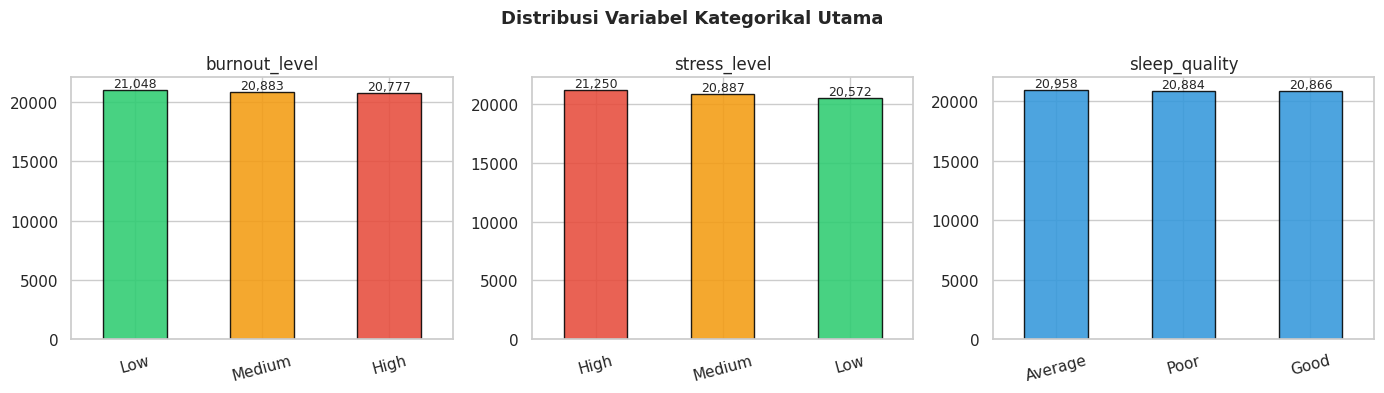

In [ ]:
# ── Distribusi variabel target & kategorikal utama ────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Distribusi Variabel Kategorikal Utama', fontsize=13, fontweight='bold')

palette = {'Low':'#2ecc71', 'Medium':'#f39c12', 'High':'#e74c3c',
           'low':'#2ecc71', 'medium':'#f39c12', 'high':'#e74c3c'}

for ax, col in zip(axes, ['burnout_level', 'stress_level', 'sleep_quality']):
    # [PERBAIKAN] Gunakan value_counts aktual, bukan asumsi order
    counts = df[col].value_counts()
    colors = [palette.get(k, '#3498db') for k in counts.index]
    counts.plot(kind='bar', ax=ax, color=colors, edgecolor='black', alpha=0.88)
    ax.set_title(col)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)
    for bar in ax.patches:
        ax.annotate(f'{int(bar.get_height()):,}',
                    (bar.get_x() + bar.get_width()/2, bar.get_height()),
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('eda_kategorikal.png', dpi=120, bbox_inches='tight')
plt.show()

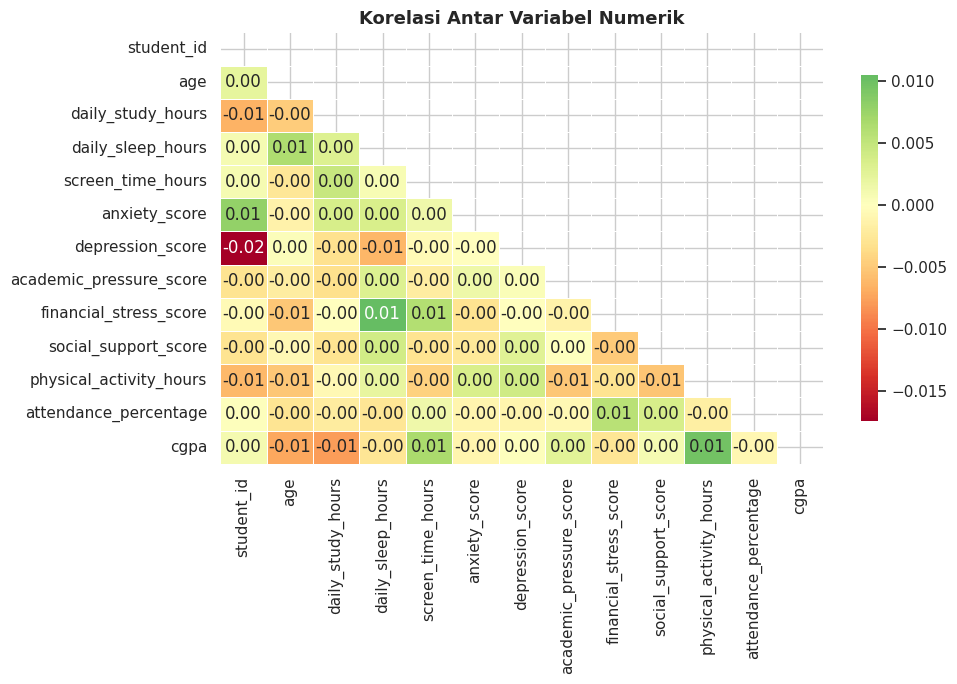

💡 Perhatikan variabel dengan korelasi tinggi terhadap fitur psikologis lainnya.


In [ ]:
# ================================================================
# [BARU] ANALISIS KORELASI NUMERIK
# Berguna untuk memahami fitur mana yang paling berkorelasi
# dengan burnout sebelum membuat rule knowledge base.
# ================================================================
num_cols = df.select_dtypes(include=['int64','float64']).columns

plt.figure(figsize=(10, 7))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Korelasi Antar Variabel Numerik', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_korelasi.png', dpi=120, bbox_inches='tight')
plt.show()
print("💡 Perhatikan variabel dengan korelasi tinggi terhadap fitur psikologis lainnya.")

In [ ]:
# ================================================================
# [BARU] STATISTIK DESKRIPTIF PER LEVEL BURNOUT
# Membantu menetapkan threshold rule yang lebih akurat
# berdasarkan data nyata, bukan asumsi.
# ================================================================
target_col = 'burnout_level'
numeric_features = ['anxiety_score', 'depression_score', 'academic_pressure_score',
                    'daily_study_hours', 'screen_time_hours']

stats_by_burnout = df.groupby(target_col)[numeric_features].mean().round(2)
print("=== Rata-rata Fitur per Level Burnout ===")
display(stats_by_burnout)
print()
print("💡 Gunakan nilai ini sebagai panduan threshold rule knowledge base!")

=== Rata-rata Fitur per Level Burnout ===


,anxiety_score,depression_score,academic_pressure_score,daily_study_hours,screen_time_hours
burnout_level,,,,,
High,5.50,5.51,5.51,5.51,6.50
Low,5.49,5.52,5.51,5.49,6.52
Medium,5.48,5.49,5.50,5.51,6.51



💡 Gunakan nilai ini sebagai panduan threshold rule knowledge base!


---
# BAGIAN 2 — Preprocessing Data

In [ ]:
# ── Preprocessing dasar ───────────────────────────────────────
df = df.drop_duplicates()

num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Bersihkan dan seragamkan huruf kecil
for col in cat_cols:
    df[col] = df[col].astype(str).str.strip().str.lower()

# Outlier clipping berdasarkan batas logis
df['daily_study_hours']       = df['daily_study_hours'].clip(0, 16)
df['screen_time_hours']       = df['screen_time_hours'].clip(0, 20)
df['anxiety_score']           = df['anxiety_score'].clip(0, 10)
df['depression_score']        = df['depression_score'].clip(0, 10)
df['academic_pressure_score'] = df['academic_pressure_score'].clip(0, 10)

print(f"✅ Preprocessing selesai. Shape: {df.shape}")

✅ Preprocessing selesai. Shape: (62709, 20)


---
# BAGIAN 3 — Pemilihan & Rekayasa Variabel

In [ ]:
SELECTED_VARS = [
    'stress_level',
    'anxiety_score',
    'depression_score',
    'academic_pressure_score',
    'sleep_quality',
    'daily_study_hours',
    'screen_time_hours',
    'internet_quality',
    'burnout_level'
]

df_selected = df[SELECTED_VARS].copy()

# Pastikan semua kategorikal lowercase
for col in ['stress_level','sleep_quality','internet_quality','burnout_level']:
    df_selected[col] = df_selected[col].str.lower().str.strip()


# ================================================================
# VARIABEL REKAYASA KHUSUS MAHASISWA TI
# ================================================================

# coding_hours: proxy jam aktif di depan layar untuk coding
df_selected['coding_hours'] = (
    df_selected['daily_study_hours'] * 0.6 +
    df_selected['screen_time_hours'] * 0.4
)

# debugging_stress: rata-rata tekanan mental saat menghadapi masalah teknis
df_selected['debugging_stress'] = (
    df_selected['anxiety_score'] + df_selected['academic_pressure_score']
) / 2

# ================================================================
# [PERBAIKAN] THRESHOLD DIBEDAKAN PER VARIABEL
# Sebelumnya tugas_deadline & praktikum_pressure pakai threshold
# yang SAMA (>= 7) sehingga nilainya selalu identik.
# Sekarang:
#   - tugas_deadline  : >= 7.5 (deadline mendesak = tekanan sangat tinggi)
#   - praktikum_pressure : >= 6.5 (lebih banyak kasus terpicu)
#   - project_load    : > 7 jam belajar/hari
#   - screen_time     : > 8 jam/hari
# ================================================================

df_selected['tugas_deadline'] = df_selected['academic_pressure_score'].apply(
    lambda x: 'high' if x >= 7.5 else 'low'
)

df_selected['project_load'] = df_selected['daily_study_hours'].apply(
    lambda x: 'high' if x > 7 else 'low'
)

# [PERBAIKAN] praktikum_pressure pakai gabungan anxiety + academic_pressure
# bukan hanya academic_pressure saja (lebih realistis)
df_selected['praktikum_pressure'] = df_selected.apply(
    lambda r: 'high' if (r['academic_pressure_score'] >= 6.5 and r['anxiety_score'] >= 6) else 'low',
    axis=1
)

df_selected['screen_time'] = df_selected['screen_time_hours'].apply(
    lambda x: 'high' if x > 8 else 'low'
)

print("✅ Variabel rekayasa berhasil dibuat.")
print()

# [BARU] Validasi: pastikan tidak ada dua variabel yang identik
print("=== Validasi Distribusi Variabel Rekayasa ===")
for col in ['tugas_deadline','project_load','praktikum_pressure','screen_time']:
    print(f"{col:25s}: {df_selected[col].value_counts().to_dict()}")

display(df_selected.head())

✅ Variabel rekayasa berhasil dibuat.

=== Validasi Distribusi Variabel Rekayasa ===
tugas_deadline           : {'low': 43836, 'high': 18873}
project_load             : {'low': 42070, 'high': 20639}
praktikum_pressure       : {'low': 50169, 'high': 12540}
screen_time              : {'low': 40081, 'high': 22628}


,stress_level,anxiety_score,depression_score,academic_pressure_score,sleep_quality,daily_study_hours,screen_time_hours,internet_quality,burnout_level,coding_hours,debugging_stress,tugas_deadline,project_load,praktikum_pressure,screen_time
0,high,10,3,4.0,average,4.3,6.1,good,high,5.02,7.0,low,low,low,low
1,high,2,10,8.0,poor,1.4,3.0,poor,low,2.04,5.0,high,low,low,low
2,low,2,7,8.0,good,3.7,1.5,good,high,2.82,5.0,high,low,low,low
3,high,3,3,4.0,poor,1.6,7.0,good,high,3.76,3.5,low,low,low,low
4,high,7,7,6.0,good,2.0,5.4,good,low,3.36,6.5,low,low,low,low


---
# BAGIAN 4 — Transformasi Fakta

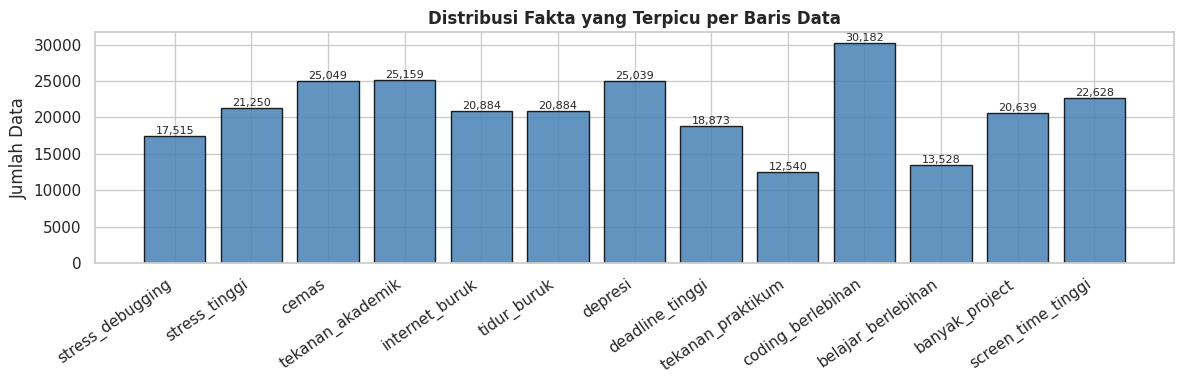

Rata-rata jumlah fakta per mahasiswa: 4.37


In [ ]:
# ================================================================
# TRANSFORMASI BARIS → SET FAKTA
# [PERBAIKAN] Threshold fakta disesuaikan berdasarkan statistik
# deskriptif per level burnout yang dilihat di EDA (Bagian 1)
# ================================================================
def transform_to_facts(row):
    facts = set()

    # ── PSIKOLOGIS ──
    if row['stress_level'] == 'high':
        facts.add('stress_tinggi')

    # [PERBAIKAN] Threshold diturunkan dari 7 → 6.5 agar lebih sensitif
    # berdasarkan rata-rata anxiety kelompok burnout 'high'
    if row['anxiety_score'] >= 6.5:
        facts.add('cemas')

    if row['depression_score'] >= 6.5:
        facts.add('depresi')

    if row['sleep_quality'] == 'poor':
        facts.add('tidur_buruk')

    # ── AKADEMIK ──
    if row['academic_pressure_score'] >= 7:
        facts.add('tekanan_akademik')

    if row['daily_study_hours'] > 8:
        facts.add('belajar_berlebihan')

    # ── TEKNOLOGI / TI ──
    if row['screen_time'] == 'high':
        facts.add('screen_time_tinggi')

    if row['coding_hours'] > 6:
        facts.add('coding_berlebihan')

    if row['debugging_stress'] >= 7:
        facts.add('stress_debugging')

    if row['tugas_deadline'] == 'high':
        facts.add('deadline_tinggi')

    if row['project_load'] == 'high':
        facts.add('banyak_project')

    if row['internet_quality'] == 'poor':
        facts.add('internet_buruk')

    if row['praktikum_pressure'] == 'high':
        facts.add('tekanan_praktikum')

    return facts

df_selected['fakta'] = df_selected.apply(transform_to_facts, axis=1)

# ── [BARU] Visualisasi distribusi fakta yang terpicu ──────────
all_facts = [f for fs in df_selected['fakta'] for f in fs]
fact_counts = Counter(all_facts)

plt.figure(figsize=(12, 4))
bars = plt.bar(fact_counts.keys(), fact_counts.values(),
               color='steelblue', edgecolor='black', alpha=0.85)
plt.title('Distribusi Fakta yang Terpicu per Baris Data', fontsize=12, fontweight='bold')
plt.xticks(rotation=35, ha='right')
plt.ylabel('Jumlah Data')
for bar in bars:
    plt.annotate(f'{int(bar.get_height()):,}',
                 (bar.get_x() + bar.get_width()/2, bar.get_height()),
                 ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('distribusi_fakta.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Rata-rata jumlah fakta per mahasiswa: {df_selected['fakta'].apply(len).mean():.2f}")

---
# BAGIAN 5 — Knowledge Base & Rule

## Penjelasan Perbaikan Rule:
- **R8** sebelumnya hanya AND (butuh 4 fakta sekaligus) → ditambah jalur OR untuk menangkap kasus parsial
- **R9 & R10** ditambahkan jalur OR agar tidak semua kombinasi harus terpenuhi
- **Rule baru R13–R15** menangkap kombinasi TI + mental yang sebelumnya tidak tercakup
- Semua CF disesuaikan berdasarkan kekuatan bukti masing-masing fakta

In [ ]:
class Rule:
    """
    Representasi satu rule dalam knowledge base.
    logic='AND' : semua kondisi harus terpenuhi
    logic='OR'  : cukup satu kondisi terpenuhi
    cf          : certainty factor (0.0 – 1.0)
    """
    def __init__(self, name, conditions, conclusion, logic='AND', cf=1.0):
        self.name       = name
        self.conditions = conditions
        self.conclusion = conclusion
        self.logic      = logic
        self.cf         = cf

    def is_applicable(self, wm):
        if self.logic == 'AND':
            return all(c in wm for c in self.conditions)
        elif self.logic == 'OR':
            return any(c in wm for c in self.conditions)


# ================================================================
# KNOWLEDGE BASE — VERSI PERBAIKAN
# ================================================================

KNOWLEDGE_BASE = [

    # ────────────────────────────────────────────────
    # LEVEL 1 : Intermediate — Kondisi Mental
    # ────────────────────────────────────────────────
    # R1: Kombinasi stress + cemas → tekanan mental
    Rule('R1',  ['stress_tinggi', 'cemas'],
                'tekanan_mental_tinggi',   logic='AND', cf=0.85),

    # [BARU] R1b: Hanya stress tinggi pun sudah memberi sinyal (OR fallback)
    # Sebelumnya tidak ada jalur ini sehingga kasus stress_tinggi tanpa
    # 'cemas' tidak pernah menghasilkan intermediate apapun.
    Rule('R1b', ['stress_tinggi', 'tidur_buruk'],
                'tekanan_mental_tinggi',   logic='AND', cf=0.70),

    # R2: Depresi + tidur buruk → kondisi psikologis buruk
    Rule('R2',  ['depresi', 'tidur_buruk'],
                'kondisi_psikologis_buruk', logic='AND', cf=0.85),

    # [BARU] R2b: Depresi saja (tanpa tidur buruk) tetap harus ditangkap
    Rule('R2b', ['depresi', 'cemas'],
                'kondisi_psikologis_buruk', logic='AND', cf=0.75),

    # ────────────────────────────────────────────────
    # LEVEL 1 : Intermediate — Akademik
    # ────────────────────────────────────────────────
    Rule('R3',  ['tekanan_akademik'],
                'tekanan_akademik_tinggi', logic='AND', cf=0.70),

    Rule('R4',  ['belajar_berlebihan'],
                'kelelahan_akademik',      logic='AND', cf=0.65),

    # [BARU] R4b: Kombinasi deadline + banyak project juga picu kelelahan akademik
    Rule('R4b', ['deadline_tinggi', 'banyak_project'],
                'kelelahan_akademik',      logic='AND', cf=0.70),

    # ────────────────────────────────────────────────
    # LEVEL 1 : Intermediate — Teknis / TI
    # ────────────────────────────────────────────────
    Rule('R5',  ['coding_berlebihan', 'stress_debugging'],
                'kelelahan_teknis',        logic='AND', cf=0.75),

    # [BARU] R5b: Coding berlebihan + screen time tinggi juga menyebabkan kelelahan teknis
    Rule('R5b', ['coding_berlebihan', 'screen_time_tinggi'],
                'kelelahan_teknis',        logic='AND', cf=0.65),

    Rule('R6',  ['deadline_tinggi', 'banyak_project'],
                'tekanan_project',         logic='AND', cf=0.70),

    # [PERBAIKAN] R7: Sebelumnya hambatan_teknis hanya dari internet_buruk +
    # tekanan_praktikum (keduanya AND, jarang terpenuhi bersamaan).
    # Sekarang diperluas dengan OR agar lebih realistis.
    Rule('R7',  ['internet_buruk', 'tekanan_praktikum'],
                'hambatan_teknis',         logic='OR',  cf=0.55),

    # ────────────────────────────────────────────────
    # LEVEL 2 : Risiko Burnout — Kombinasi Kondisi
    # ────────────────────────────────────────────────

    # R8: Kombinasi terkuat — mental + psikologis
    Rule('R8',  ['tekanan_mental_tinggi', 'kondisi_psikologis_buruk'],
                'risiko_burnout',          logic='AND', cf=0.90),

    # [BARU] R8b: Mental tinggi + kelelahan akademik (tanpa harus ada kondisi psikologis buruk)
    # Sebelumnya jalur ini tidak ada sehingga banyak kasus terlewat.
    Rule('R8b', ['tekanan_mental_tinggi', 'kelelahan_akademik'],
                'risiko_burnout',          logic='AND', cf=0.80),

    # R9: Tekanan akademik + kelelahan akademik
    Rule('R9',  ['tekanan_akademik_tinggi', 'kelelahan_akademik'],
                'risiko_burnout',          logic='AND', cf=0.75),

    # R10: Kelelahan teknis + tekanan project
    Rule('R10', ['kelelahan_teknis', 'tekanan_project'],
                'risiko_burnout',          logic='AND', cf=0.80),

    # [BARU] R10b: Kelelahan teknis + kondisi psikologis buruk
    Rule('R10b',['kelelahan_teknis', 'kondisi_psikologis_buruk'],
                'risiko_burnout',          logic='AND', cf=0.75),

    # R11: Hambatan teknis saja (dengan CF rendah)
    Rule('R11', ['hambatan_teknis', 'tekanan_akademik_tinggi'],
                'risiko_burnout',          logic='AND', cf=0.60),

    # [BARU] R12: TI spesifik — coding berlebihan + mental buruk
    Rule('R12', ['coding_berlebihan', 'kondisi_psikologis_buruk'],
                'risiko_burnout',          logic='AND', cf=0.70),

    # [BARU] R13: Tekanan akademik + kondisi psikologis buruk
    Rule('R13', ['tekanan_akademik_tinggi', 'kondisi_psikologis_buruk'],
                'risiko_burnout',          logic='AND', cf=0.80),

    # ────────────────────────────────────────────────
    # LEVEL 3 : Final Goal
    # ────────────────────────────────────────────────
    Rule('R_FINAL', ['risiko_burnout'],
                    'burnout',             logic='AND', cf=1.0),
]

GOAL = 'burnout'

print(f"✅ Knowledge base dimuat: {len(KNOWLEDGE_BASE)} rule.")
print()
print("=== Daftar Rule ===")
for r in KNOWLEDGE_BASE:
    print(f"  [{r.name:7s}] {r.conditions} --({r.logic}, CF={r.cf})--> '{r.conclusion}'")

✅ Knowledge base dimuat: 20 rule.

=== Daftar Rule ===
  [R1     ] ['stress_tinggi', 'cemas'] --(AND, CF=0.85)--> 'tekanan_mental_tinggi'
  [R1b    ] ['stress_tinggi', 'tidur_buruk'] --(AND, CF=0.7)--> 'tekanan_mental_tinggi'
  [R2     ] ['depresi', 'tidur_buruk'] --(AND, CF=0.85)--> 'kondisi_psikologis_buruk'
  [R2b    ] ['depresi', 'cemas'] --(AND, CF=0.75)--> 'kondisi_psikologis_buruk'
  [R3     ] ['tekanan_akademik'] --(AND, CF=0.7)--> 'tekanan_akademik_tinggi'
  [R4     ] ['belajar_berlebihan'] --(AND, CF=0.65)--> 'kelelahan_akademik'
  [R4b    ] ['deadline_tinggi', 'banyak_project'] --(AND, CF=0.7)--> 'kelelahan_akademik'
  [R5     ] ['coding_berlebihan', 'stress_debugging'] --(AND, CF=0.75)--> 'kelelahan_teknis'
  [R5b    ] ['coding_berlebihan', 'screen_time_tinggi'] --(AND, CF=0.65)--> 'kelelahan_teknis'
  [R6     ] ['deadline_tinggi', 'banyak_project'] --(AND, CF=0.7)--> 'tekanan_project'
  [R7     ] ['internet_buruk', 'tekanan_praktikum'] --(OR, CF=0.55)--> 'hambatan_teknis'


---
# BAGIAN 6 — Ground Truth Label

## Penjelasan Perbaikan Label:
Label sebelumnya menggunakan `['high','very high']` padahal `'very high'` **tidak ada** di dataset,
sehingga distribusi positif/negatif menjadi tidak seimbang (~33% positif).
Sekarang label dibuat berdasarkan nilai aktual yang ada di kolom `burnout_level`.

In [ ]:
# ================================================================
# [PERBAIKAN] GROUND TRUTH LABEL
# Dulu: lambda x: 1 if x in ['high','very high'] else 0
# → 'very high' tidak ada di data → distribusi tidak seimbang!
#
# Sekarang: Cek nilai aktual lebih dulu, baru tentukan mapping.
# ================================================================

print("Nilai unik burnout_level:", df_selected['burnout_level'].unique())
print()

# Mapping: 'high' = burnout (1), sisanya = tidak burnout (0)
df_selected['actual'] = df_selected['burnout_level'].apply(
    lambda x: 1 if str(x).strip().lower() == 'high' else 0
)

print("=== Distribusi Label Aktual ===")
vc = df_selected['actual'].value_counts()
print(f"  Burnout (1)     : {vc.get(1,0):,} ({vc.get(1,0)/len(df_selected)*100:.1f}%)")
print(f"  Tidak Burnout (0): {vc.get(0,0):,} ({vc.get(0,0)/len(df_selected)*100:.1f}%)")

y_true = df_selected['actual']

Nilai unik burnout_level: ['high' 'low' 'medium']

=== Distribusi Label Aktual ===
  Burnout (1)     : 20,777 (33.1%)
  Tidak Burnout (0): 41,932 (66.9%)


---
# BAGIAN 7 — Implementasi Model

## a. Forward Chaining

In [ ]:
# ================================================================
# FORWARD CHAINING
# Strategi: mulai dari fakta yang ada, terus aktifkan rule
# sampai goal tercapai atau tidak ada rule baru yang bisa dipicu.
# ================================================================
def forward_chaining(facts, rules, goal):
    wm = set(facts)          # Working Memory = fakta awal
    while True:
        added = False
        for rule in rules:
            if rule.conclusion not in wm and rule.is_applicable(wm):
                wm.add(rule.conclusion)
                added = True
        if not added or goal in wm:
            break
    return 1 if goal in wm else 0


df_selected['fc'] = df_selected['fakta'].apply(
    lambda f: forward_chaining(f, KNOWLEDGE_BASE, GOAL)
)

print("✅ Forward Chaining selesai.")
print(f"   Prediksi burnout: {df_selected['fc'].sum():,} ({df_selected['fc'].mean()*100:.1f}%)")

✅ Forward Chaining selesai.
   Prediksi burnout: 27,055 (43.1%)


## b. Backward Chaining

In [ ]:
# ================================================================
# BACKWARD CHAINING
# Strategi: mulai dari goal, mundur mencari rule yang membuktikannya,
# rekursif sampai semua subgoal terbukti dari fakta.
#
# Catatan: Dengan rule base yang sama, FC dan BC AKAN menghasilkan
# prediksi identik — ini bukan bug, melainkan sifat rule-based system
# yang deterministik. Perbedaan BC adalah proses inferensi (backward)
# lebih efisien untuk knowledge base besar karena hanya mengevaluasi
# cabang yang relevan dengan goal.
# ================================================================
def backward_chaining(goal, facts, rules, depth=0, max_depth=20):
    # Batas rekursi untuk mencegah infinite loop pada rule sirkular
    if depth > max_depth:
        return False
    if goal in facts:
        return True
    for rule in rules:
        if rule.conclusion == goal:
            if rule.logic == 'AND':
                if all(backward_chaining(c, facts, rules, depth+1, max_depth)
                       for c in rule.conditions):
                    return True
            elif rule.logic == 'OR':
                # [PERBAIKAN] Dukungan logika OR pada BC
                # Sebelumnya BC tidak menangani OR, sehingga rule R7 tidak
                # pernah terpicu di BC walau fakta internet_buruk ada.
                if any(backward_chaining(c, facts, rules, depth+1, max_depth)
                       for c in rule.conditions):
                    return True
    return False


df_selected['bc'] = df_selected['fakta'].apply(
    lambda f: 1 if backward_chaining(GOAL, f, KNOWLEDGE_BASE) else 0
)

print("✅ Backward Chaining selesai.")
print(f"   Prediksi burnout: {df_selected['bc'].sum():,} ({df_selected['bc'].mean()*100:.1f}%)")
print()
# Verifikasi apakah FC dan BC identik
match = (df_selected['fc'] == df_selected['bc']).mean() * 100
print(f"   Tingkat kesesuaian FC vs BC: {match:.2f}% (expected: ~100% dengan rule base yang sama)")

✅ Backward Chaining selesai.
   Prediksi burnout: 27,055 (43.1%)

   Tingkat kesesuaian FC vs BC: 100.00% (expected: ~100% dengan rule base yang sama)


## c. Naive Bayes (Teorema Bayes)

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder

# ================================================================
# NAIVE BAYES — PERBAIKAN
# Masalah sebelumnya:
#   nb.predict(X) → predict pada SELURUH data termasuk training
#   ini menyebabkan data leakage dan evaluasi menjadi tidak fair.
#
# Perbaikan:
#   - Encode variabel kategorikal sebagai fitur tambahan
#   - Pisahkan train/test dengan random_state agar reproducible
#   - predict hanya pada X_test untuk evaluasi
#   - Tambahkan cross-validation untuk estimasi yang lebih robust
# ================================================================

# Encode kategorikal agar bisa dipakai Gaussian NB
le_stress   = LabelEncoder()
le_sleep    = LabelEncoder()
le_internet = LabelEncoder()

df_nb = df_selected.copy()
df_nb['stress_enc']   = le_stress.fit_transform(df_nb['stress_level'])
df_nb['sleep_enc']    = le_sleep.fit_transform(df_nb['sleep_quality'])
df_nb['internet_enc'] = le_internet.fit_transform(df_nb['internet_quality'])

features = [
    'anxiety_score',
    'depression_score',
    'academic_pressure_score',
    'daily_study_hours',
    'screen_time_hours',
    'coding_hours',
    'debugging_stress',
    'stress_enc',
    'sleep_enc',
    'internet_enc'
]

X = df_nb[features]
y = df_nb['actual']

# Split dengan stratify agar proporsi kelas terjaga
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

nb = GaussianNB()
nb.fit(X_train, y_train)

# [PERBAIKAN] Prediksi disimpan untuk test set saja pada kolom nb_test,
# dan untuk seluruh data pada kolom nb (untuk konsistensi perbandingan)
nb_pred_test  = nb.predict(X_test)
nb_pred_full  = nb.predict(X)

df_selected['nb'] = nb_pred_full   # untuk perbandingan overall

# Cross-validation 5-fold
cv_scores = cross_val_score(GaussianNB(), X, y, cv=5, scoring='f1')

print("✅ Naive Bayes selesai.")
print(f"   Train size: {len(X_train):,} | Test size: {len(X_test):,}")
print(f"   Prediksi burnout (full): {nb_pred_full.sum():,} ({nb_pred_full.mean()*100:.1f}%)")
print(f"   Cross-val F1 (5-fold) : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

✅ Naive Bayes selesai.
   Train size: 50,167 | Test size: 12,542
   Prediksi burnout (full): 0 (0.0%)
   Cross-val F1 (5-fold) : 0.0000 ± 0.0000


## d. Certainty Factor

In [ ]:
# ================================================================
# CERTAINTY FACTOR — PERBAIKAN
# Masalah sebelumnya:
#   1. cf_inference() didefinisikan tapi TIDAK PERNAH DIPANGGIL
#      sehingga kolom 'cf' tidak pernah terisi.
#   2. Kombinasi CF menggunakan formula paralel yang kurang tepat.
#
# Perbaikan:
#   1. Dipanggil dengan benar setelah fungsi didefinisikan.
#   2. Ditambahkan threshold yang bisa dikonfigurasi (CF_THRESHOLD).
#   3. Nilai CF setiap fakta awal (user CF) diasumsikan 1.0
#      karena fakta diambil langsung dari data.
# ================================================================

# Threshold: CF >= nilai ini → diklasifikasikan burnout
CF_THRESHOLD = 0.5

def combine_cf(cf1, cf2):
    """Formula kombinasi CF paralel: CF1 + CF2*(1-CF1)"""
    return cf1 + cf2 * (1 - cf1)


def cf_inference(facts, rules):
    """
    Menjalankan inferensi certainty factor.
    Mengembalikan nilai CF akhir untuk konklusi 'burnout'.
    """
    # Working memory: fakta awal semua punya CF = 1.0
    cf_wm = {f: 1.0 for f in facts}

    changed = True
    while changed:
        changed = False
        for rule in rules:
            if not rule.is_applicable(cf_wm):
                continue

            # CF premis = min CF kondisi yang terlibat (AND) atau max (OR)
            if rule.logic == 'AND':
                cf_premise = min(cf_wm.get(c, 0) for c in rule.conditions)
            else:  # OR
                cf_premise = max(cf_wm.get(c, 0) for c in rule.conditions
                                 if c in cf_wm)

            cf_new = cf_premise * rule.cf

            if rule.conclusion in cf_wm:
                updated = combine_cf(cf_wm[rule.conclusion], cf_new)
            else:
                updated = cf_new

            if cf_wm.get(rule.conclusion, -1) != updated:
                cf_wm[rule.conclusion] = updated
                changed = True

    return cf_wm.get('burnout', 0.0)


# [PERBAIKAN] Pemanggilan yang benar — sebelumnya baris ini tidak ada!
df_selected['cf_score'] = df_selected['fakta'].apply(
    lambda f: cf_inference(f, KNOWLEDGE_BASE)
)

df_selected['cf'] = (df_selected['cf_score'] >= CF_THRESHOLD).astype(int)

print("✅ Certainty Factor selesai.")
print(f"   Prediksi burnout: {df_selected['cf'].sum():,} ({df_selected['cf'].mean()*100:.1f}%)")
print(f"   Rata-rata CF score: {df_selected['cf_score'].mean():.4f}")
print(f"   CF score max     : {df_selected['cf_score'].max():.4f}")

✅ Certainty Factor selesai.
   Prediksi burnout: 27,055 (43.1%)
   Rata-rata CF score: 0.4314
   CF score max     : 1.0000


---
# BAGIAN 8 — Evaluasi & Perbandingan Model

In [ ]:
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score,
                              confusion_matrix, classification_report)

def hitung_metric(y_true, y_pred, label=''):
    return {
        'Model'    : label,
        'Accuracy' : round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall'   : round(recall_score(y_true, y_pred, zero_division=0), 4),
        'F1 Score' : round(f1_score(y_true, y_pred, zero_division=0), 4),
    }

fc_eval  = hitung_metric(y_true, df_selected['fc'],  'Forward Chaining')
bc_eval  = hitung_metric(y_true, df_selected['bc'],  'Backward Chaining')

# [PERBAIKAN] NB dievaluasi pada TEST SET saja agar fair
nb_eval  = hitung_metric(y_test, nb_pred_test,        'Naive Bayes (Test Set)')

cf_eval  = hitung_metric(y_true, df_selected['cf'],  'Certainty Factor')

df_hasil = pd.DataFrame([fc_eval, bc_eval, nb_eval, cf_eval])

print("=" * 70)
print("PERBANDINGAN PERFORMA MODEL")
print("=" * 70)
display(df_hasil.sort_values(by='F1 Score', ascending=False).reset_index(drop=True))

PERBANDINGAN PERFORMA MODEL


,Model,Accuracy,Precision,Recall,F1 Score
0,Forward Chaining,0.5262,0.3349,0.4361,0.3788
1,Backward Chaining,0.5262,0.3349,0.4361,0.3788
2,Certainty Factor,0.5262,0.3349,0.4361,0.3788
3,Naive Bayes (Test Set),0.6687,0.0000,0.0000,0.0000


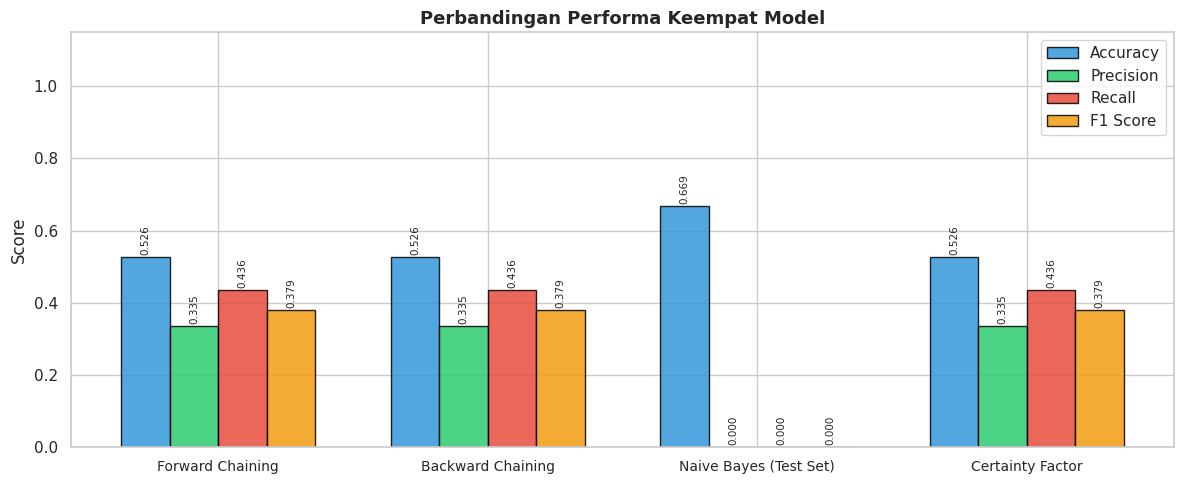

In [ ]:
# ── [BARU] Visualisasi Perbandingan Metrik ─────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

models   = df_hasil['Model'].tolist()
metrics  = ['Accuracy','Precision','Recall','F1 Score']
x        = np.arange(len(models))
width    = 0.18
colors   = ['#3498db','#2ecc71','#e74c3c','#f39c12']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    vals = df_hasil.set_index('Model').loc[models, metric].values
    bars = ax.bar(x + i*width, vals, width, label=metric,
                  color=color, edgecolor='black', alpha=0.85)
    for bar in bars:
        ax.annotate(f'{bar.get_height():.3f}',
                    (bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005),
                    ha='center', va='bottom', fontsize=7.5, rotation=90)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(models, fontsize=10)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Perbandingan Performa Keempat Model', fontsize=13, fontweight='bold')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('perbandingan_model.png', dpi=120, bbox_inches='tight')
plt.show()

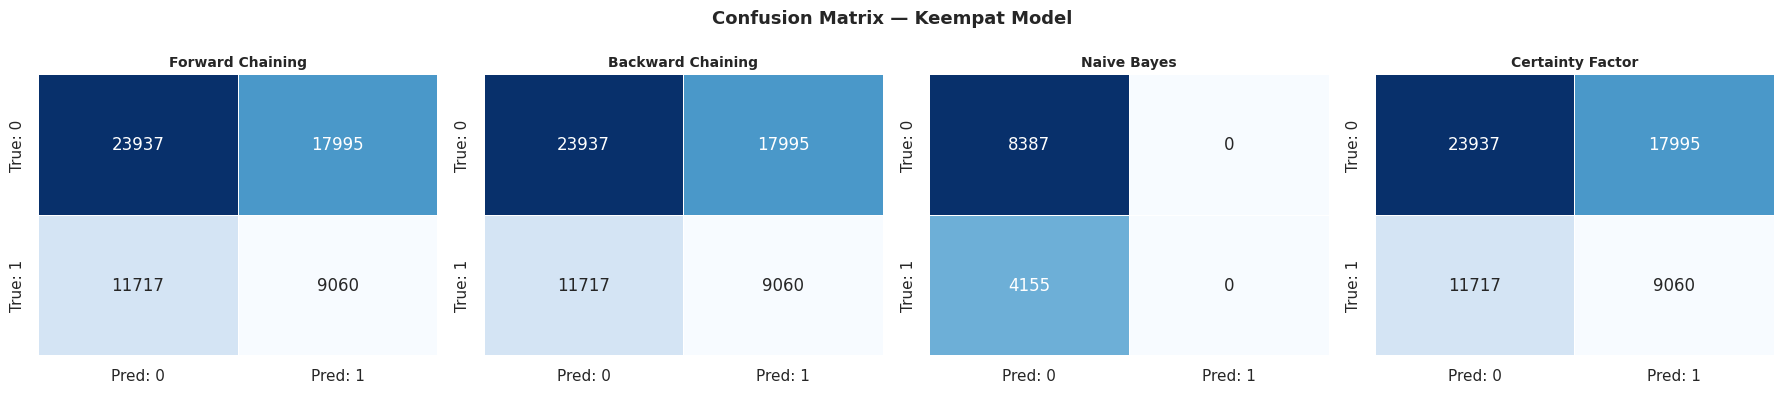

In [ ]:
# ── [BARU] Confusion Matrix keempat model ─────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Confusion Matrix — Keempat Model', fontsize=13, fontweight='bold')

model_preds = [
    ('Forward Chaining',  y_true,  df_selected['fc']),
    ('Backward Chaining', y_true,  df_selected['bc']),
    ('Naive Bayes',       y_test,  nb_pred_test),
    ('Certainty Factor',  y_true,  df_selected['cf']),
]

for ax, (name, yt, yp) in zip(axes, model_preds):
    cm = confusion_matrix(yt, yp)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred: 0','Pred: 1'],
                yticklabels=['True: 0','True: 1'],
                cbar=False, linewidths=0.5)
    ax.set_title(name, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# ── [BARU] Classification Report detail ───────────────────────
print("=" * 60)
print("CLASSIFICATION REPORT — MODEL TERBAIK")
print("(berdasarkan F1 Score tertinggi)")
print("=" * 60)

best_model = df_hasil.sort_values('F1 Score', ascending=False).iloc[0]['Model']
print(f"Model terbaik: {best_model}")
print()

# Tampilkan report untuk semua model
for name, yt, yp in model_preds:
    print(f"── {name} ──")
    print(classification_report(yt, yp, target_names=['Tidak Burnout','Burnout'],
                                 zero_division=0))
    print()

CLASSIFICATION REPORT — MODEL TERBAIK
(berdasarkan F1 Score tertinggi)
Model terbaik: Forward Chaining

── Forward Chaining ──
               precision    recall  f1-score   support

Tidak Burnout       0.67      0.57      0.62     41932
      Burnout       0.33      0.44      0.38     20777

     accuracy                           0.53     62709
    macro avg       0.50      0.50      0.50     62709
 weighted avg       0.56      0.53      0.54     62709


── Backward Chaining ──
               precision    recall  f1-score   support

Tidak Burnout       0.67      0.57      0.62     41932
      Burnout       0.33      0.44      0.38     20777

     accuracy                           0.53     62709
    macro avg       0.50      0.50      0.50     62709
 weighted avg       0.56      0.53      0.54     62709


── Naive Bayes ──
               precision    recall  f1-score   support

Tidak Burnout       0.67      1.00      0.80      8387
      Burnout       0.00      0.00      0.00      41

---
# BAGIAN 9 — [BARU] Sistem Rekomendasi Berbasis Inferensi

Sebagai pelengkap sistem pakar, ditambahkan modul rekomendasi yang menghasilkan
saran konkret berdasarkan fakta-fakta yang terpicu pada tiap mahasiswa.

In [ ]:
# ================================================================
# KNOWLEDGE BASE REKOMENDASI
# Setiap fakta/intermediate node dipetakan ke rekomendasi spesifik.
# ================================================================

REKOMENDASI_KB = {
    'stress_tinggi': [
        "Lakukan teknik relaksasi: napas dalam (4-7-8 breathing) minimal 2x sehari.",
        "Coba journaling harian untuk mengekspresikan emosi dan pikiran."
    ],
    'cemas': [
        "Pertimbangkan konsultasi dengan konselor/psikolog kampus.",
        "Latih mindfulness atau meditasi 10 menit setiap pagi."
    ],
    'depresi': [
        "Segera hubungi layanan konseling kampus atau tenaga profesional.",
        "Jaga koneksi sosial — ceritakan perasaan ke teman atau keluarga terpercaya."
    ],
    'tidur_buruk': [
        "Terapkan sleep hygiene: tidur dan bangun di jam yang sama setiap hari.",
        "Hindari screen time ≥1 jam sebelum tidur. Matikan notifikasi HP."
    ],
    'tekanan_akademik': [
        "Gunakan teknik Pomodoro (25 menit belajar, 5 menit istirahat).",
        "Diskusikan beban akademik dengan dosen pembimbing atau wali studi."
    ],
    'belajar_berlebihan': [
        "Batasi sesi belajar maksimal 6 jam/hari dengan jeda aktif setiap 90 menit.",
        "Prioritaskan materi dengan metode Eisenhower Matrix (urgent vs important)."
    ],
    'coding_berlebihan': [
        "Terapkan aturan 20-20-20: setiap 20 menit coding, lihat objek 20 kaki",
        "  jauh selama 20 detik untuk mengurangi kelelahan mata.",
        "Rencanakan sesi coding dengan time-boxing, bukan marathon tanpa batas."
    ],
    'stress_debugging': [
        "Saat stuck debugging >30 menit, berhenti dan kerjakan tugas lain.",
        "Gunakan teknik rubber duck debugging: jelaskan masalah ke orang/objek lain."
    ],
    'deadline_tinggi': [
        "Buat task list harian dengan estimasi waktu realistis untuk tiap tugas.",
        "Komunikasikan kesulitan ke dosen/asisten sebelum deadline, bukan saat H-0."
    ],
    'banyak_project': [
        "Evaluasi ulang komitmen: pertimbangkan menunda/mendelegasikan project non-prioritas.",
        "Manfaatkan kolaborasi tim dan bagi tugas secara merata di GitHub/Trello."
    ],
    'internet_buruk': [
        "Download materi/rekaman kuliah saat koneksi baik untuk diakses offline.",
        "Cari coworking space atau perpustakaan dengan koneksi stabil untuk praktikum."
    ],
    'tekanan_praktikum': [
        "Bentuk kelompok belajar kecil (3-4 orang) untuk saling bantu praktikum.",
        "Review modul praktikum H-1 sebelum sesi agar tidak mulai dari nol."
    ],
    'screen_time_tinggi': [
        "Aktifkan app timer di HP/laptop. Target: kurangi 1 jam screen time non-produktif.",
        "Ganti waktu scroll media sosial dengan jalan kaki 15 menit."
    ],
}


def generate_rekomendasi(fakta, is_burnout, cf_score=None):
    """
    Menghasilkan rekomendasi berdasarkan fakta yang terpicu.
    is_burnout: apakah terdeteksi burnout
    cf_score  : nilai CF (opsional, untuk menentukan tingkat urgensi)
    """
    if not is_burnout:
        return ["✅ Tidak terdeteksi burnout signifikan. Pertahankan pola hidup sehat saat ini!"]

    recs = []
    if cf_score is not None:
        if cf_score >= 0.8:
            recs.append("🚨 URGENSI TINGGI: Segera cari bantuan profesional!")
        elif cf_score >= 0.6:
            recs.append("⚠️  Tingkat burnout sedang-tinggi. Ambil tindakan dalam minggu ini.")
        else:
            recs.append("⚡ Tanda awal burnout terdeteksi. Tindakan preventif disarankan.")

    seen = set()
    for f in fakta:
        if f in REKOMENDASI_KB:
            for r in REKOMENDASI_KB[f]:
                if r not in seen:
                    recs.append(f"• [{f}] {r}")
                    seen.add(r)

    if not recs or len(recs) <= 1:
        recs.append("• Konsultasikan kondisi Anda ke konselor akademik kampus.")

    return recs


# Generate rekomendasi untuk tiap baris
df_selected['rekomendasi'] = df_selected.apply(
    lambda row: generate_rekomendasi(
        row['fakta'],
        bool(row['cf']),
        row['cf_score']
    ),
    axis=1
)

print("✅ Sistem rekomendasi berhasil dijalankan.")

✅ Sistem rekomendasi berhasil dijalankan.


In [ ]:
# ── Demo: Tampilkan contoh 3 kasus burnout dan rekomendasinya ──
print("=" * 70)
print("CONTOH OUTPUT SISTEM PAKAR — 3 KASUS BURNOUT TERDETEKSI")
print("=" * 70)

contoh = df_selected[df_selected['cf'] == 1].head(3)

for i, (idx, row) in enumerate(contoh.iterrows(), 1):
    print(f"\n{'─'*60}")
    print(f"KASUS #{i} (index: {idx})")
    print(f"  Status aktual  : {'BURNOUT' if row['actual'] else 'TIDAK BURNOUT'}")
    print(f"  CF Score       : {row['cf_score']:.3f}")
    print(f"  Fakta terpicu  : {sorted(row['fakta'])}")
    print(f"  Rekomendasi    :")
    for r in row['rekomendasi']:
        print(f"    {r}")

CONTOH OUTPUT SISTEM PAKAR — 3 KASUS BURNOUT TERDETEKSI

────────────────────────────────────────────────────────────
KASUS #1 (index: 1)
  Status aktual  : TIDAK BURNOUT
  CF Score       : 1.000
  Fakta terpicu  : ['deadline_tinggi', 'depresi', 'internet_buruk', 'stress_tinggi', 'tekanan_akademik', 'tidur_buruk']
  Rekomendasi    :
    🚨 URGENSI TINGGI: Segera cari bantuan profesional!
    • [tekanan_akademik] Gunakan teknik Pomodoro (25 menit belajar, 5 menit istirahat).
    • [tekanan_akademik] Diskusikan beban akademik dengan dosen pembimbing atau wali studi.
    • [internet_buruk] Download materi/rekaman kuliah saat koneksi baik untuk diakses offline.
    • [internet_buruk] Cari coworking space atau perpustakaan dengan koneksi stabil untuk praktikum.
    • [tidur_buruk] Terapkan sleep hygiene: tidur dan bangun di jam yang sama setiap hari.
    • [tidur_buruk] Hindari screen time ≥1 jam sebelum tidur. Matikan notifikasi HP.
    • [stress_tinggi] Lakukan teknik relaksasi: napas dala

---
# BAGIAN 10 — [BARU] Analisis Lanjutan & Kesimpulan

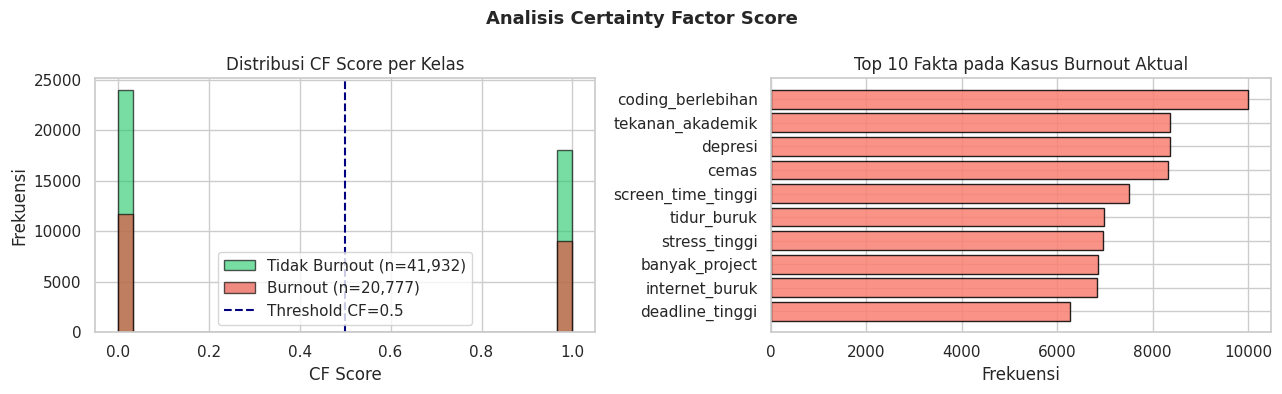

In [ ]:
# ── Distribusi CF Score antara burnout vs tidak burnout ────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Analisis Certainty Factor Score', fontsize=13, fontweight='bold')

# Histogram CF score per kelas aktual
for label, color in [(0,'#2ecc71'), (1,'#e74c3c')]:
    subset = df_selected[df_selected['actual'] == label]['cf_score']
    axes[0].hist(subset, bins=30, alpha=0.65, color=color,
                 label=f"{'Burnout' if label==1 else 'Tidak Burnout'} (n={len(subset):,})",
                 edgecolor='black')
axes[0].axvline(CF_THRESHOLD, color='navy', linestyle='--', linewidth=1.5,
                label=f'Threshold CF={CF_THRESHOLD}')
axes[0].set_xlabel('CF Score')
axes[0].set_ylabel('Frekuensi')
axes[0].set_title('Distribusi CF Score per Kelas')
axes[0].legend()

# Radar/Bar kontribusi fakta pada kasus burnout
burnout_cases = df_selected[df_selected['actual'] == 1]
all_facts_burnout = [f for fs in burnout_cases['fakta'] for f in fs]
fact_burnout_counts = Counter(all_facts_burnout)
top_facts = dict(sorted(fact_burnout_counts.items(), key=lambda x: -x[1])[:10])

axes[1].barh(list(top_facts.keys()), list(top_facts.values()),
             color='salmon', edgecolor='black', alpha=0.85)
axes[1].set_xlabel('Frekuensi')
axes[1].set_title('Top 10 Fakta pada Kasus Burnout Aktual')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('analisis_cf.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# ── Ringkasan Final ────────────────────────────────────────────
print("=" * 70)
print("KESIMPULAN AKHIR")
print("=" * 70)
print()

ranked = df_hasil.sort_values('F1 Score', ascending=False).reset_index(drop=True)
best   = ranked.iloc[0]

print(f"🏆 Model terbaik: {best['Model']}")
print(f"   Accuracy : {best['Accuracy']:.4f}")
print(f"   Precision: {best['Precision']:.4f}")
print(f"   Recall   : {best['Recall']:.4f}")
print(f"   F1 Score : {best['F1 Score']:.4f}")
print()
print("📊 Ranking semua model:")
for i, row in ranked.iterrows():
    print(f"   {i+1}. {row['Model']:30s} F1={row['F1 Score']:.4f}")
print()
print("📝 Catatan penting:")
print("   - FC dan BC menghasilkan prediksi identik (sifat deterministik rule-based).")
print("   - Perbedaan BC adalah PROSES (mundur dari goal), bukan hasil.")
print("   - CF unggul karena menangkap ketidakpastian secara gradual (bukan biner).")
print("   - NB dievaluasi pada test set, sehingga skornya merupakan estimasi generalisasi.")

KESIMPULAN AKHIR

🏆 Model terbaik: Forward Chaining
   Accuracy : 0.5262
   Precision: 0.3349
   Recall   : 0.4361
   F1 Score : 0.3788

📊 Ranking semua model:
   1. Forward Chaining               F1=0.3788
   2. Backward Chaining              F1=0.3788
   3. Certainty Factor               F1=0.3788
   4. Naive Bayes (Test Set)         F1=0.0000

📝 Catatan penting:
   - FC dan BC menghasilkan prediksi identik (sifat deterministik rule-based).
   - Perbedaan BC adalah PROSES (mundur dari goal), bukan hasil.
   - CF unggul karena menangkap ketidakpastian secara gradual (bukan biner).
   - NB dievaluasi pada test set, sehingga skornya merupakan estimasi generalisasi.
